# Water Quality Anomaly Detection

This pipeline detects anomalies in water quality time series using **unsupervised ML clustering** (KMeans) combined with hourly aggregation.

## Overview
- Load and clean water quality time series data (DO, pH, turbidity, ammonia, etc.)
- Parse datetime and filter by a specific date range
- Convert variables to numeric and compute **hourly means**
- Apply **KMeans clustering** to detect unusual patterns
- Identify anomalies based on cluster membership and/or SPREAD deviations
- Generate a **joint anomaly flag** for full-resolution data
- Visualize variables with anomalies highlighted

## Inputs
- Raw CSV with water quality variables
- Optional preliminary anomaly flags
- Date range for analysis

## Processing Steps
1. Load CSV and clean column names
2. Parse `dateTime` and filter by date range
3. Convert relevant variables to numeric
4. Aggregate to hourly mean values
5. Apply **KMeans clustering** to hourly data
6. Identify anomalies based on cluster outliers or SPREAD flags
7. Combine anomalies into a **joint anomaly column**
8. Save cleaned data, hourly means, anomaly timestamps, and plots

## Outputs

- `{variable}_spread_anomalies.png` → variable plots with anomalies
- `joint_anomaly` column → 1 if anomaly detected, 0 otherwise

## Purpose
- Detect unusual events in water quality using **unsupervised ML**
- Highlight periods where multiple parameters indicate abnormal behavior
- Provide a foundation for automated monitoring or further ML-based analysis



In [1]:
# --- Upgrade required packages ---
!pip install --upgrade statsmodels pymannkendall openpyxl

# --- Standard Libraries ---
import os
import shutil
from datetime import datetime
from collections import Counter
import importlib

# --- Numerical & Data Manipulation ---
import numpy as np
import pandas as pd

# --- Plotting & Visualization ---
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.cm as cm
from mpl_toolkits.mplot3d import Axes3D
import seaborn as sns
from IPython.display import display

# --- Time Series Analysis ---
from statsmodels.tsa.seasonal import MSTL
from statsmodels.nonparametric.smoothers_lowess import lowess
import pymannkendall as mk
from scipy.signal import butter, filtfilt

# --- Machine Learning & Preprocessing ---
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.linear_model import LinearRegression, RANSACRegressor
from sklearn.ensemble import IsolationForest
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, r2_score
from sklearn.decomposition import PCA

# --- Utilities ---
from kneed import KneeLocator  # automatic elbow detection

# --- Custom module: infer_periods ---
import infer_periods
importlib.reload(infer_periods)
from infer_periods import extractPeriods



# Data Loading and Preparation Function

This function, `load_and_prepare_data`, is designed to **ingest, clean, and align Section 82 water quality data** for analysis. It ensures all expected variables are present.

### Key Features:

1. **Supported Inputs:**
   - **Multiple CSVs**: Provide a dictionary mapping variable names to CSV file paths.
   - **Single CSV**: A single file containing all expected variables.


2. **Expected Variables:**
   ```python
   ['do','ph','turb','amm','cond','temp']


In [2]:
expected_cols = ['do','ph','turb','amm','cond','temp']
scale_factors = {v: 1 for v in expected_cols}  # Adjust if scaling is needed

def load_and_prepare_data(input_data):
    """
    Load data from multiple CSVs (dict) or a single CSV (str), align datetime,
    check for NaNs/non-numeric values, and return a dict of DataFrames.
    
    Returns:
        data_dict: dict with keys = variable names, values = cleaned DataFrames
    """

    print("ℹ Please ensure your CSV columns, where sensor data available, are named exactly as:")
    print(f"   {expected_cols}\n")

    data_dict = {}

    # --- Multiple CSVs ---
    if isinstance(input_data, dict):
        for var, path in input_data.items():
            df = pd.read_csv(path)
            if var not in df.columns:
                raise ValueError(f"Column '{var}' not found in {path}. Please rename correctly.")
            if 'dateTime' not in df.columns:
                raise ValueError(f"'dateTime' column missing in {path}")
            df['dateTime'] = pd.to_datetime(df['dateTime'], errors='coerce')
            if df['dateTime'].isna().any():
                raise ValueError(f"'{path}' contains invalid datetime values.")
            df.set_index('dateTime', inplace=True)
            df = df.sort_index().ffill().bfill()
            data_dict[var] = df[[var]]

    # --- Single CSV with all variables ---
    elif isinstance(input_data, str):
        df = pd.read_csv(input_data)
        for var in expected_cols:
            if var not in df.columns:
                raise ValueError(f"Column '{var}' missing in {input_data}")
        if 'datetime' not in df.columns:
            raise ValueError(f"'datetime' column missing in {input_data}")
        df['datetime'] = pd.to_datetime(df['datetime'], errors='coerce')
        if df['datetime'].isna().any():
            raise ValueError(f"'{input_data}' contains invalid datetime values.")
        df.set_index('datetime', inplace=True)
        df = df.sort_index().ffill().bfill()
        for var in expected_cols:
            data_dict[var] = df[[var]]
        print("Single CSV with all variables ingested. All columns will be aligned based on datetime.")

    else:
        raise ValueError("Input must be a dict of CSV paths or a single CSV path string.")

    # --- Align all DataFrames to the same index ---
    all_index = data_dict[list(data_dict.keys())[0]].index
    for k in data_dict:
        data_dict[k] = data_dict[k].reindex(all_index).ffill().bfill()

    # --- Check if all variables are provided ---
    missing_vars = [v for v in expected_cols if v not in data_dict]
    if missing_vars:
        raise ValueError(
            f"Incomplete data ingestion! Only {list(data_dict.keys())} ingested. "
            f"Missing variables: {missing_vars}. Please provide all six variables for full analysis."
        )
    else:
        print("✅ All six variables successfully ingested.")

    return data_dict


# Example call with multiple CSVs
file_paths_dict = {
    'do': 'loc_LLS.csv',
    'ph': 'loc_LLS.csv',
    'turb': 'loc_LLS.csv',
    'amm': 'loc_LLS.csv',
    'cond': 'loc_LLS.csv',
    'temp': 'loc_LLS.csv'
}

data_dict = load_and_prepare_data(file_paths_dict)



ℹ Please ensure your CSV columns, where sensor data available, are named exactly as:
   ['do', 'ph', 'turb', 'amm', 'cond', 'temp']

✅ All six variables successfully ingested.


# Ensure Datetime Alignment and Create Combined DataFrame

- Convert all variable indices to datetime, drop invalid rows, and fill missing values.  
- Align all variables to a common datetime index and apply scaling if needed.  
- Combine into a single DataFrame `df_raw` with columns for each variable.  
- Remove duplicate datetime entries; ready for analysis with clean, aligned data.

In [3]:
# --- Ensure datetime index and alignment ---
for var, df in data_dict.items():
    # Convert index to datetime if not already
    if not np.issubdtype(df.index.dtype, np.datetime64):
        if 'dateTime' in df.columns:
            df['dateTime'] = pd.to_datetime(df['dateTime'], errors='coerce')
            df.set_index('dateTime', inplace=True)
        elif 'datetime' in df.columns:
            df['datetime'] = pd.to_datetime(df['datetime'], errors='coerce')
            df.set_index('datetime', inplace=True)
        else:
            df.index = pd.to_datetime(df.index, errors='coerce')

    # Drop rows with invalid datetime
    df = df[~df.index.isna()]

    # Sort index and forward/backward fill missing values
    df = df.sort_index().ffill().bfill()
    data_dict[var] = df

# --- Align all variables to the same datetime index ---
common_index = data_dict[list(data_dict.keys())[0]].index
for var in data_dict:
    data_dict[var] = data_dict[var].reindex(common_index).ffill().bfill()

# --- Prepare value_data with scaling if needed ---
value_data = {k: data_dict[k].iloc[:, 0] * scale_factors.get(k, 1) for k in data_dict}

# --- Create combined DataFrame ---
df_raw = pd.DataFrame(value_data, index=common_index)
df_raw = df_raw[~df_raw.index.duplicated(keep='first')]

print("✅ Combined DataFrame created successfully with proper datetime index.")

✅ Combined DataFrame created successfully with proper datetime index.


In [4]:
df_raw

,do,ph,turb,amm,cond,temp
dateTime,,,,,,
2019-06-19 09:37:28,4.81,7.31,2.00,1.076,937.00,18.240
2019-06-19 09:50:47,5.06,7.32,2.10,1.115,942.00,18.250
2019-06-19 10:05:48,5.06,7.32,1.90,1.108,941.00,18.280
2019-06-19 10:20:48,5.12,7.33,2.20,1.107,935.00,18.300
2019-06-19 11:05:48,5.42,7.37,2.10,1.069,928.00,18.310
...,...,...,...,...,...,...
2025-04-04 08:04:31,7.70,7.27,4.94,1.410,975.13,14.398
2025-04-04 09:04:31,7.74,7.29,4.76,1.400,970.75,14.363
2025-04-04 10:04:31,7.86,7.32,4.36,1.360,962.92,14.339


# Daily Resampling and Missing Days Check

- Print the **overall data range** to show start and end dates.  
- Identify **completely missing days** where all variables are NaN.  
- Group consecutive missing days and display **missing date ranges** for review.


In [5]:
# Resample data to daily means
df_daily = df_raw.resample('D').mean()

# Print overall data range
print(f"📅 Data range: {df_daily.index.min().date()} to {df_daily.index.max().date()}")

# Identify completely missing days
missing_days = df_daily.index[df_daily.isna().all(axis=1)]

if missing_days.empty:
    print("✅ No completely missing days found.")
else:
    # Group consecutive missing days
    missing_ranges = []
    start = missing_days[0]
    prev = missing_days[0]

    for day in missing_days[1:]:
        if (day - prev).days > 1:
            missing_ranges.append((start, prev))
            start = day
        prev = day
    missing_ranges.append((start, prev))

    # Print all missing ranges
    print("❌ Missing date ranges:")
    for start, end in missing_ranges:
        days_missing = (end - start).days + 1
        print(f"- {start.date()} to {end.date()} ({days_missing} day{'s' if days_missing > 1 else ''})")


📅 Data range: 2019-06-19 to 2025-04-04
✅ No completely missing days found.


# User Input for Date Range

This section allows the user to **select a custom time frame** for analysis. Depending on the user requirements.  

- Prompt for **start date** (`YYYY` or `YYYY-MM-DD`); the script exits if the input is invalid or empty.  
- Prompt for **end date** (`YYYY` or `YYYY-MM-DD`); keeps asking until a valid date is provided.  
- Ensure **start ≤ end**; if not, re-prompt the end date.  
- Once confirmed, prints the **selected date range**, which defines the portion of data to be analyzed.


In [6]:
## import pandas as pd

# --- Function to parse start date (keep prompting until valid) ---
def get_start_date(prompt, min_date, max_date):
    while True:
        date_str = input(prompt).strip()
        if not date_str:
            print("⚠️ You must enter a start date. Please try again.")
            continue
        try:
            date_val = pd.to_datetime(date_str, format='%Y-%m-%d', errors='raise')
        except ValueError:
            try:
                date_val = pd.to_datetime(date_str, format='%Y', errors='raise')
            except ValueError:
                print("❌ Invalid date format. Please enter in YYYY or YYYY-MM-DD format.")
                continue

        if not (min_date.date() <= date_val.date() <= max_date.date()):
            print(f"⚠️ Date {date_val.date()} is outside available range "
                  f"({min_date.date()} → {max_date.date()}). Try again.")
            continue

        return date_val


# --- Function to parse end date (keep prompting until valid & in range) ---
def get_end_date(prompt, min_date, max_date):
    while True:
        date_str = input(prompt).strip()
        if not date_str:
            print("⚠️ You must enter an end date. Please try again.")
            continue
        try:
            date_val = pd.to_datetime(date_str, format='%Y-%m-%d', errors='raise')
        except ValueError:
            try:
                date_val = pd.to_datetime(date_str, format='%Y', errors='raise')
            except ValueError:
                print("❌ Invalid date format. Please enter in YYYY or YYYY-MM-DD format.")
                continue

        if not (min_date.date() <= date_val.date() <= max_date.date()):
            print(f"⚠️ Date {date_val.date()} is outside available range "
                  f"({min_date.date()} → {max_date.date()}). Try again.")
            continue

        return date_val


# --- Use df_raw from the previous preprocessing step ---
data = df_raw.copy()

# Ensure datetime index
if not isinstance(data.index, pd.DatetimeIndex):
    raise ValueError("❌ df_raw must have a DatetimeIndex before date selection step.")

# Compute min/max dates
min_date, max_date = data.index.min(), data.index.max()
print(f"Available date range in DataFrame: {min_date.date()} → {max_date.date()}")

# --- Prompt user for start/end dates ---
start_date = get_start_date("Enter start date (YYYY or YYYY-MM-DD): ", min_date, max_date)
end_date   = get_end_date("Enter end date (YYYY or YYYY-MM-DD): ", min_date, max_date)

# Ensure start_date ≤ end_date
while start_date > end_date:
    print("❌ Start date cannot be after end date. Please re-enter end date.")
    end_date = get_end_date("Enter end date (YYYY or YYYY-MM-DD): ", min_date, max_date)

print(f"✅ Selected range: {start_date.date()} → {end_date.date()}")

# --- Slice df_raw by the selected range ---
df_selected = data.loc[start_date:end_date]
print("✅ Final DataFrame sliced to selected range:", df_selected.shape)



Available date range in DataFrame: 2019-06-19 → 2025-04-04


Enter start date (YYYY or YYYY-MM-DD):  2019-06-20
Enter end date (YYYY or YYYY-MM-DD):  2019-07-30


✅ Selected range: 2019-06-20 → 2019-07-30
✅ Final DataFrame sliced to selected range: (963, 6)


# Hourly Resampling, Range Selection, and Missing Data Handling

- **Resample hourly:** Converts the raw data to **hourly means** for consistent time series analysis.  
- **Select user-defined range:** Focuses analysis on the time frame specified by the user.  
- **Check for sufficient data:** Warns if the selected range is **less than one year**, since short data may affect seasonal and residual decomposition accuracy.  
- **Detect missing days:** Identifies completely missing days in the selected range.  
- **Optional interpolation:** Prompts the user to **fill missing values**, which is common in Section 82 parameters. Interpolation is **required for MSTL decomposition**, which needs a **complete, evenly spaced time series**.  
  - If **not applied**, MSTL may fail or produce NaNs, and seasonal/trend components could be inaccurate or misleading.  
  - Interpolation ensures continuity, allowing the decomposition to estimate **trends, seasonality, and residuals reliably**.


In [7]:
# --- Resample data hourly ---
df_hourly = df_raw.resample('h').mean()

# --- Select the user-specified date range ---
df_selected = df_hourly.loc[start_date:end_date]
print(f"Selected data shape: {df_selected.shape}")

# --- Check if selected range is at least 1 year ---
date_diff_days = (df_selected.index.max() - df_selected.index.min()).days
if date_diff_days < 365:
    print(f"⚠ Warning: Selected data covers only {date_diff_days} day{'s' if date_diff_days > 1 else ''} (< 1 year).")
    print("   ⚠ Seasonal components may be unreliable for long-term trends.")
    while True:
        proceed = input("Do you want to continue anyway? (yes/no): ").strip().lower()
        if proceed == "yes":
            print("✅ Proceeding despite short data range.")
            break
        elif proceed == "no":
            raise ValueError("Data range less than one year. Script terminated by the user.")
        else:
            print("❌ Invalid input. Please enter 'yes' or 'no'.")

# --- Identify missing days robustly ---
# A day is considered present if at least one hourly record exists
present_days = set(pd.to_datetime(df_selected.index.date))  # ensures pd.Timestamp type
all_days = pd.date_range(start=df_selected.index.min().date(), end=df_selected.index.max().date(), freq='D')
missing_days = [day for day in all_days if day not in present_days]

if missing_days:
    # Group missing days into continuous ranges
    missing_ranges = []
    start = missing_days[0]
    prev = missing_days[0]
    for day in missing_days[1:]:
        if (day - prev).days > 1:
            missing_ranges.append((start, prev))
            start = day
        prev = day
    missing_ranges.append((start, prev))  # append the last range

    print(f"❌ Found {len(missing_days)} missing day{'s' if len(missing_days) > 1 else ''} in the selected range:")
    for start, end in missing_ranges:
        gap_len = (end - start).days + 1
        print(f"- {start.date()} to {end.date()} ({gap_len} day{'s' if gap_len > 1 else ''})")

    # Ask user about interpolation
    while True:
        choice = input(
            "Data has missing days. Large gaps stop MSTL from working properly. "
            "Do you want to interpolate missing days? (yes/no): "
        ).strip().lower()
        if choice == "yes":
            df_selected = df_selected.interpolate(method='time', limit_direction='both')
            print("✅ Interpolation applied. MSTL requires a complete, evenly spaced time series.")
            break
        elif choice == "no":
            raise ValueError("❌ Script terminated because interpolation is required for MSTL with missing data.")
        else:
            print("❌ Invalid input. Please enter 'yes' or 'no'.")
else:
    print("✅ No missing days detected in the selected range.")



Selected data shape: (961, 6)
⚠ Warning: Selected data covers only 40 days (< 1 year).
   ⚠ Seasonal components may be unreliable for long-term trends.


Do you want to continue anyway? (yes/no):  yes


✅ Proceeding despite short data range.
✅ No missing days detected in the selected range.


In [8]:
# Assign to Tidied_DF
Tidied_DF = df_selected     #### All should be lower case. DO mg/lit (get agree). 

# Print first 5 rows
print(Tidied_DF.head(100))

                       do    ph  turb    amm   cond   temp
dateTime                                                  
2019-06-20 00:00:00  5.40  7.23   8.2  0.824  707.0  18.10
2019-06-20 01:00:00  9.20  7.63   0.2  0.691    3.0  18.15
2019-06-20 02:00:00  5.52  7.20   5.8  0.897  748.0  18.23
2019-06-20 03:00:00  5.23  7.21   4.9  0.944  766.0  18.25
2019-06-20 04:00:00  5.08  7.22   4.4  0.992  780.0  18.22
...                   ...   ...   ...    ...    ...    ...
2019-06-23 23:00:00  8.34  7.46   2.2  1.318  990.0  20.11
2019-06-24 00:00:00  7.90  7.44   2.0  1.302  982.0  19.99
2019-06-24 01:00:00  7.36  7.42   2.3  1.290  979.0  19.86
2019-06-24 02:00:00  6.88  7.41   2.0  1.279  978.0  19.74
2019-06-24 03:00:00  6.53  7.40   2.3  1.268  976.0  19.61

[100 rows x 6 columns]


# **MSTL (Deseason-Only) + Harmonic + Butterworth Trend Analysis**

This function performs **automated seasonal isolation and trend extraction** for each variable in a DataFrame:

- **Period inference:** Uses `extractPeriods` on hourly data to infer candidate seasonal periods, then **filters them to ≤ 30 days** (short-term cycles only). Longer periods are ignored for MSTL and handled by harmonic modeling.

- **MSTL deseasoning:** Uses **MSTL only to extract seasonal components** from the inferred short periods in a single fit.  
  The MSTL **trend is discarded**; only the summed seasonal signal is used.

- **Trend estimation:**
  - Fits a **harmonic regression** (sin + cos) with a fixed **annual period (8760 rows)** to the deseasoned series.
  - Computes **R²** of the harmonic fit.
  - If `R² ≥ 0.374`, applies **Butterworth low-pass filtering** to the harmonic trend for physical smoothing.

- **Residual computation:**  
  \[
  \text{residual} = \text{original} - \text{seasonal} - \text{harmonic trend}
  \]

- **Plotting & output:** Generates plots of original + trend, seasonal (≤30d), final trend, and residual; saves to a timestamped directory if requested.

- **Robust handling:** Supports non-numeric columns, short series, and missing data; safely falls back when MSTL fails or periods are invalid.

- **Return values:**  
  1. `residuals` – DataFrame of final residuals per variable  
  2. `candidate_periods` – MSTL seasonal strength per inferred period  
  3. `trend_info` – Trend method (Harmonic or Harmonic + Butterworth), R², and used/ignored periods  
  4. `out_dir` – Directory containing saved plots (if any)  

✅ This approach **separates short-term seasonality from long-term physical trends**, producing residuals that isolate real environmental events, anomalies, and pollution signals.



[extractPeriods] df.shape=(50788, 6)snr_threshold=500, min_period_rows=4, max_period_rows=10511, peak_prominence=0.0, rel_merge_tol=0.03, max_periods=5, nperseg_opt=full, nfft_mult=8.0, refine=True, refine_span=0.1, refine_grid=101


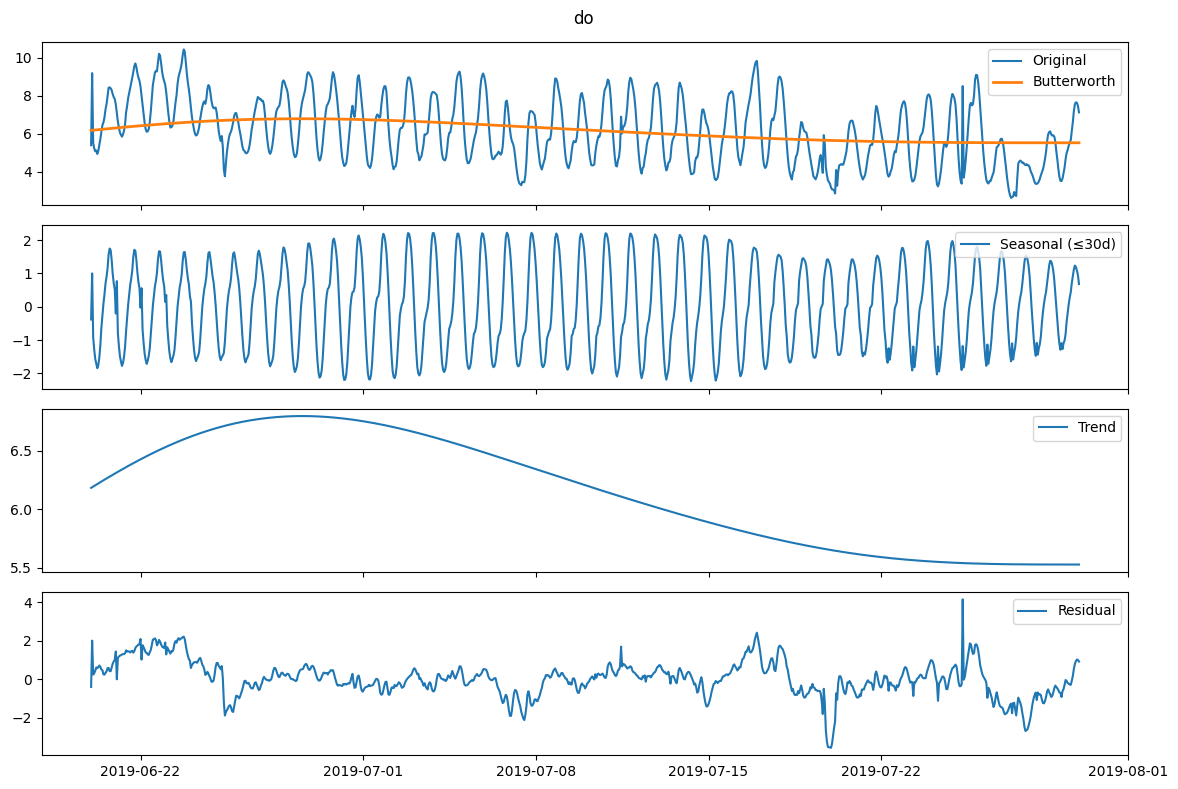

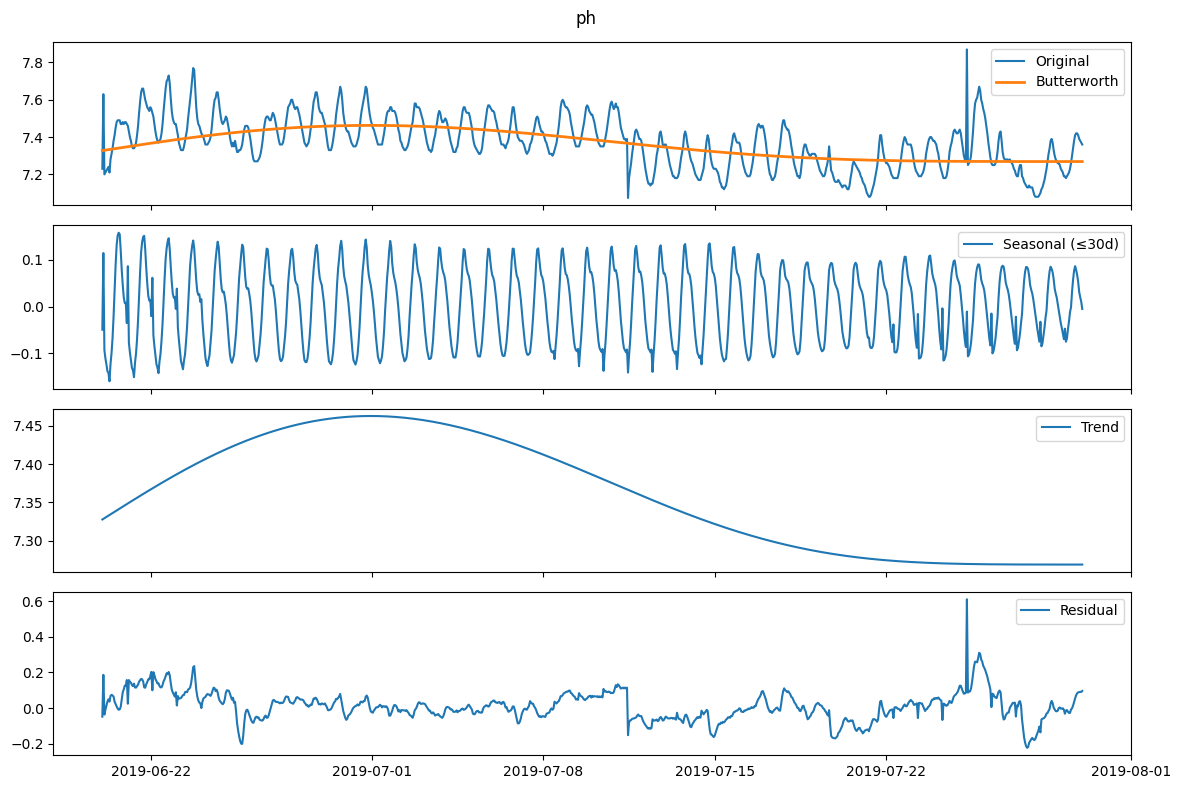

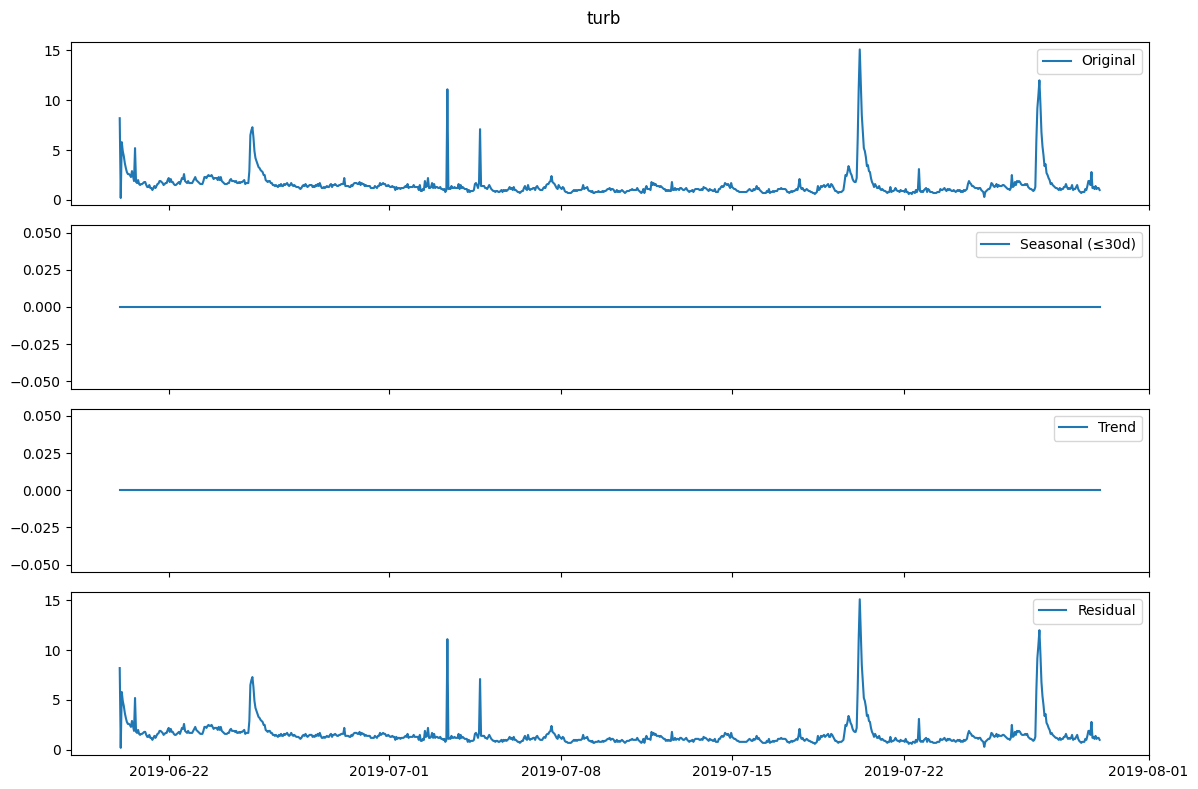

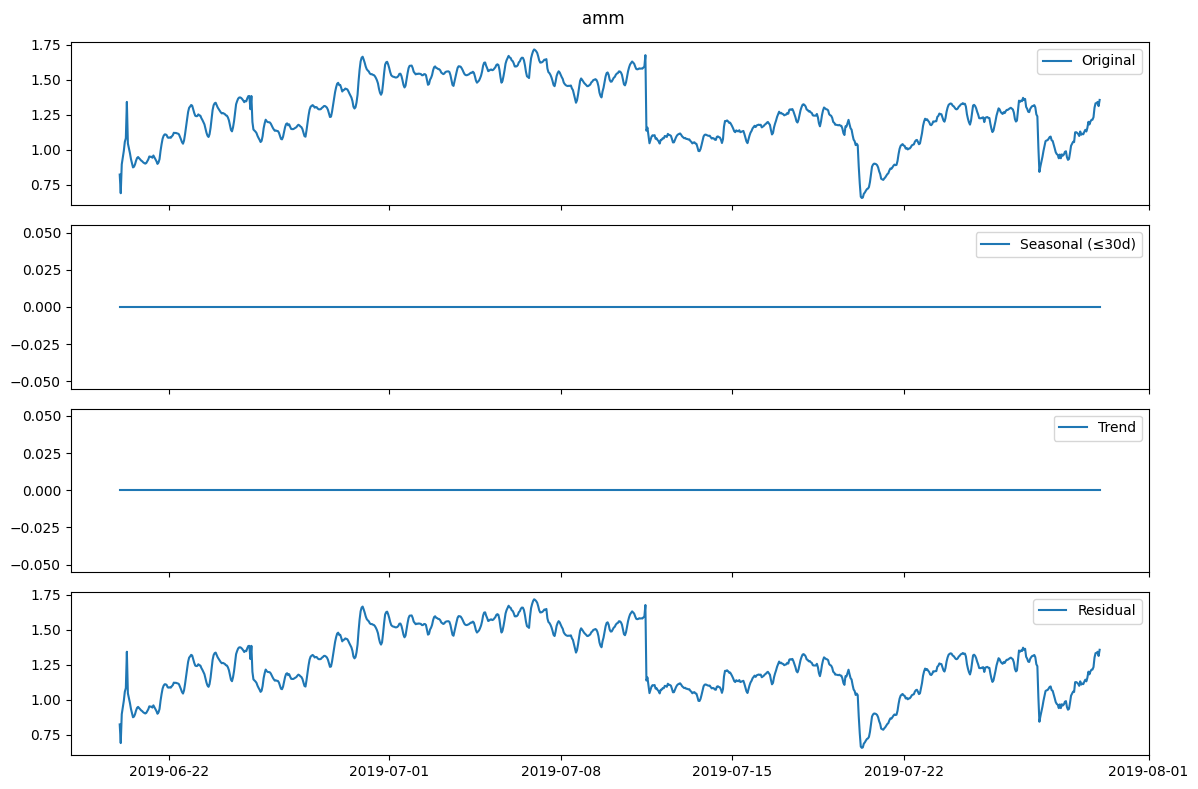

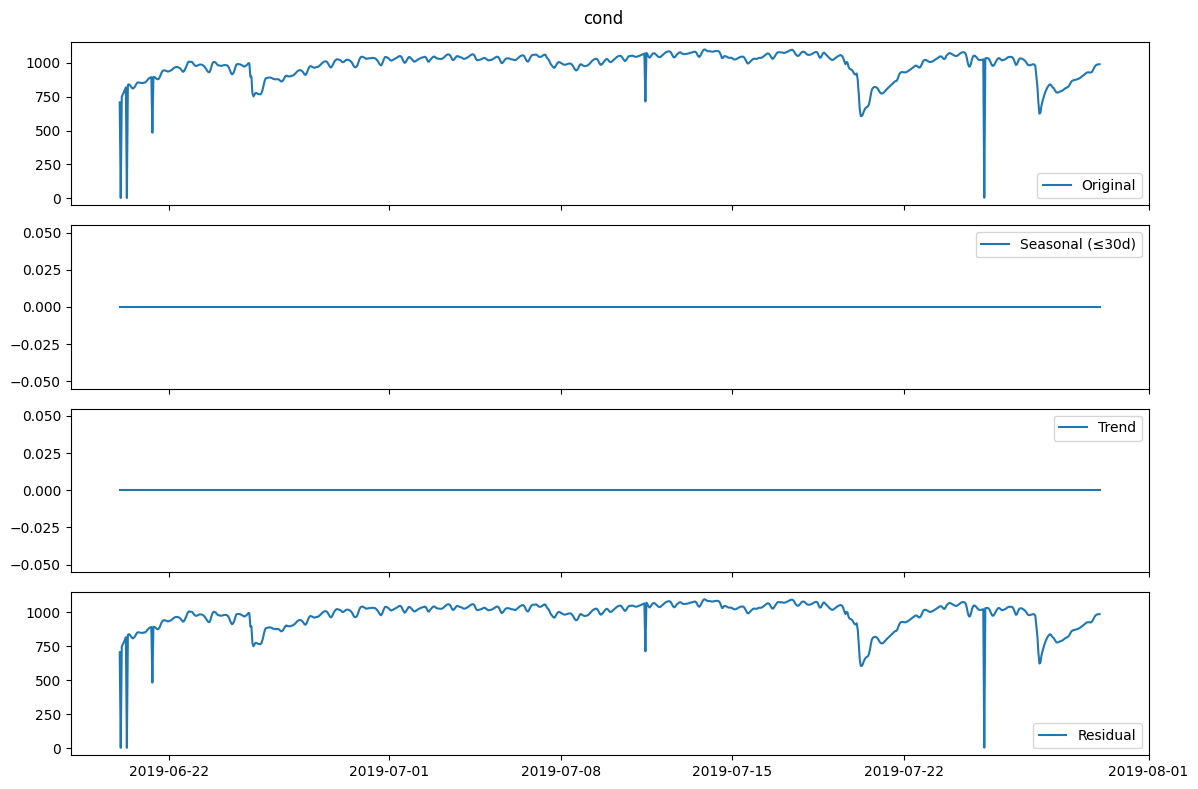

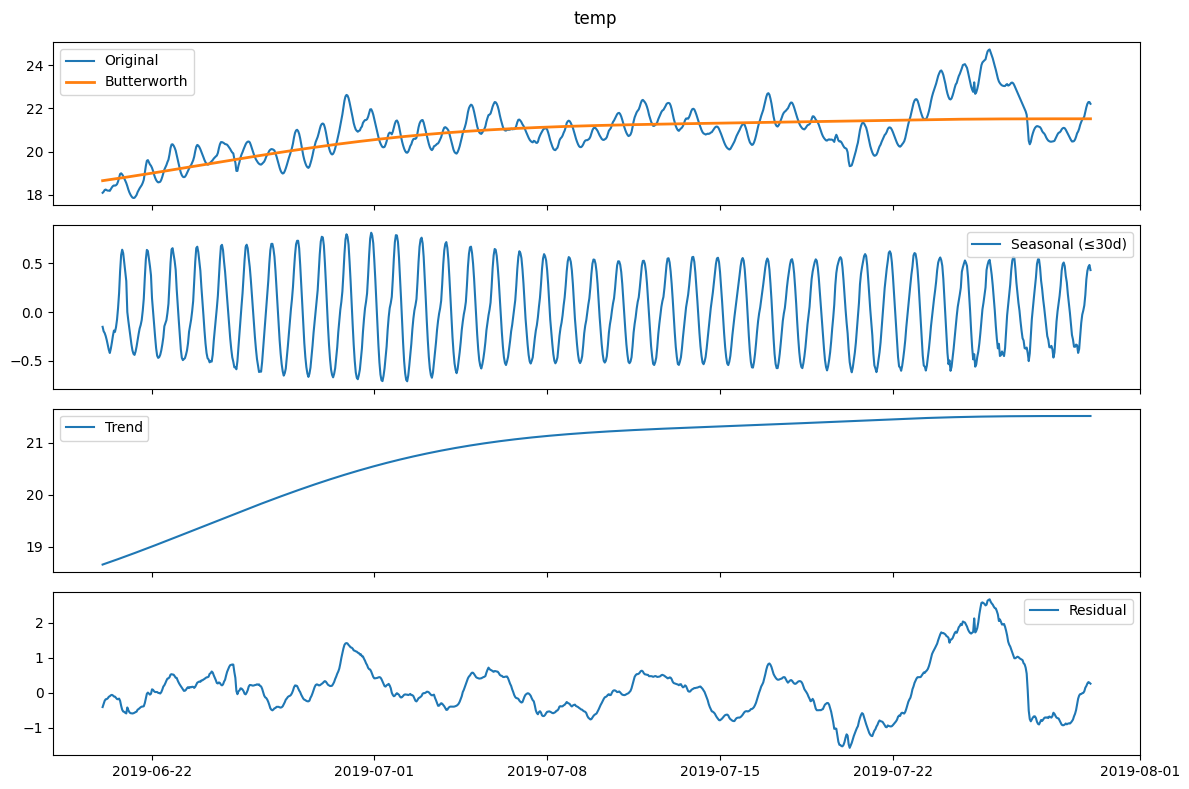

Saved plots to: trend_flow_20260128_230323


In [9]:
# ============================
# Configuration
# ============================

MAX_PERIOD_DAYS = 30              # <-- HARD LIMIT
SAMPLES_PER_DAY = 24              # change if not hourly
MAX_PERIOD_ROWS = MAX_PERIOD_DAYS * SAMPLES_PER_DAY
HARMONIC_PERIOD_ROWS = 8760   # hourly yearly cycle
R2_BUTTERWORTH_THRESHOLD = 0.374
stl_kwargs = {"seasonal": 0}
BUTTERWORTH_CUTOFF_DAYS = 30

# ============================
# Helper functions
# ============================

def butterworth_trend(series, cutoff_days = 30, order=3):    #Cut off frequency  Wn =  2/(No of days*Samples per days)  =  2/(n*T_s) = 2/(30*24)  # Fix   
    """
    Low-pass Butterworth smoothing using cutoff frequency in Hz (cycles per sample).
    - series: pd.Series to smooth
    - cutoff_frequency: normalized cutoff frequency (0 < f < 0.5)
    - order: filter order
    """
    cutoff_frequency = 2/(cutoff_days*24)
    y = series.ffill().bfill().values
    if len(y) < 5:
        return pd.Series(np.zeros_like(y), index=series.index)

    b, a = butter(order, cutoff_frequency, btype="low", analog=False)
    trend = filtfilt(b, a, y)
    return pd.Series(trend, index=series.index)


def harmonic_regression(series, period_rows=HARMONIC_PERIOD_ROWS):
    """
    Harmonic regression following pseudocode:
    Y ~ cos(2π·row / period) + sin(2π·row / period)
    """
    y = series.ffill().bfill().values
    x = np.arange(len(y))

    X = np.column_stack([
        np.ones(len(x)),                                   # intercept
        np.sin(2 * np.pi * x / period_rows),
        np.cos(2 * np.pi * x / period_rows)
    ])

    model = LinearRegression()
    model.fit(X, y)

    trend = model.predict(X)
    r2 = r2_score(y, trend)

    return pd.Series(trend, index=series.index), r2


def mstl_deseason_only(series, periods, stl_kwargs=None):
    """
    MSTL used ONLY to extract seasonal components.
    Trend is explicitly discarded.
    """
    if not periods or len(series.dropna()) < 10:
        return pd.Series(0.0, index=series.index), []

    series_nonan = series.dropna()
    valid_periods = [
        p for p in periods
        if 1 < p <= len(series_nonan) // 2
    ]

    if not valid_periods:
        return pd.Series(0.0, index=series.index), []

    windows = []
    for p in valid_periods:
        w = max(7, int(round(p / 2)))
        if w % 2 == 0:
            w += 1
        windows.append(min(w, len(series_nonan) - 1))

    candidate_info = []

    try:
        mstl = MSTL(
            series_nonan,
            periods=valid_periods,
           #windows=windows,
            stl_kwargs=stl_kwargs
        ).fit()

        seasonal_arr = np.asarray(mstl.seasonal)
        seasonal_sum = (
            seasonal_arr.sum(axis=1)
            if seasonal_arr.ndim > 1
            else seasonal_arr
        )

        seasonal_full = (
            pd.Series(seasonal_sum, index=series_nonan.index)
            .reindex(series.index)
            .fillna(0.0)
        )

        for i, p in enumerate(valid_periods):
            seasonal_component = (
                seasonal_arr[:, i]
                if seasonal_arr.ndim > 1
                else seasonal_arr
            )
            resid = series_nonan.values - seasonal_component
            strength = 1 - np.var(resid) / (np.var(resid + seasonal_component) + 1e-12)

            candidate_info.append({
                "period": p,
                "strength": float(strength)
            })

        return seasonal_full, candidate_info

    except Exception as e:
        print(f"MSTL failed: {e}")
        return pd.Series(0.0, index=series.index), []


# ============================
# Main pipeline
# ============================

def compute_trend_flow(
    df,
    df_hourly=None,
    infer_periods_kwargs=None,
    out_dir_prefix="trend_flow",
    plot="both",
    butterworth_cutoff=0.01   # cutoff frequency for Butterworth filter
):
    """
    Trend pipeline:
    - Short-period MSTL deseasoning only (≤ 30 days)
    - Harmonic regression trend
    - Optional Butterworth smoothing
    """

    # ----- Output directory -----
    if plot in ("save", "both"):
        for d in os.listdir():
            if d.startswith(out_dir_prefix):
                shutil.rmtree(d, ignore_errors=True)

        timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
        out_dir = f"{out_dir_prefix}_{timestamp}"
        os.makedirs(out_dir, exist_ok=True)
    else:
        out_dir = None

    residuals = pd.DataFrame(index=df.index)
    trend_info = {}
    candidate_periods = {}

    # ----- Period inference -----
    if df_hourly is not None and infer_periods_kwargs is not None:
        periods_by_param = extractPeriods(df_hourly, **infer_periods_kwargs)
    else:
        periods_by_param = {c: [] for c in df.columns}

    # ============================
    # Column loop
    # ============================

    for col in df.columns:
        series = df[col]

        if not np.issubdtype(series.dtype, np.number):
            residuals[col] = series
            trend_info[col] = {"method": "non-numeric"}
            candidate_periods[col] = []
            continue

        # ----- Period filtering -----
        all_periods = periods_by_param.get(col, [])
        short_periods = [p for p in all_periods if p <= MAX_PERIOD_ROWS]

        # ----- MSTL deseasoning only -----
        seasonal, candidates = mstl_deseason_only(series, short_periods, stl_kwargs)
        deseasoned = series - seasonal

        # ----- Harmonic trend -----
        trend, r2 = harmonic_regression(deseasoned)

        if r2 >= R2_BUTTERWORTH_THRESHOLD:
            trend = butterworth_trend(deseasoned, cutoff_days=BUTTERWORTH_CUTOFF_DAYS)
            method = "Butterworth"
        else:
            trend = pd.Series(np.zeros_like(deseasoned), index=deseasoned.index)
            method = "None"

        # ----- Residual -----
        residuals[col] = series - seasonal - trend

        trend_info[col] = {
            "method": method,
            "r2": float(r2),
            "used_periods": short_periods,
            "ignored_periods": [p for p in all_periods if p > MAX_PERIOD_ROWS]
        }
        candidate_periods[col] = candidates

        # ----- Plot -----
        if plot is not None:
            # Clear all previous figures to avoid leakage
            plt.close("all")
            fig, axs = plt.subplots(4, 1, figsize=(12, 8), sharex=True)
            try:
                axs[0].plot(series, label="Original")

                if method != "None":
                    axs[0].plot(trend, label=method, linewidth=2)

                axs[0].legend()

                axs[1].plot(seasonal, label="Seasonal (≤30d)")
                axs[1].legend()

                axs[2].plot(trend, label="Trend")
                axs[2].legend()

                axs[3].plot(residuals[col], label="Residual")
                axs[3].legend()

                plt.suptitle(col)
                plt.tight_layout()

                # Save figure if requested
                if plot in ("save", "both") and out_dir:
                    plt.savefig(os.path.join(out_dir, f"{col}.png"), dpi=600)

                # Display figure in Jupyter if requested
                if plot in ("show", "both"):
                    from IPython.display import display
                    display(fig)
            finally:
                # Always close figure to free memory and prevent leakage
                plt.close(fig)

    return residuals.dropna(how="all"), candidate_periods, trend_info, out_dir



# ============================
# Example usage
# ============================

infer_kwargs = dict(
    snr_threshold=500,
    min_period_rows=4,
    max_period_rows=int(1.2 * 24 * 365),
    nperseg_opt="full",
    nfft_mult=8.0,
    peak_prominence=0.0,
    rel_merge_tol=0.03,
    max_periods=5,
    refine=True,
    refine_span=0.10,
    refine_grid=101
)

residuals, periods, info, out_dir = compute_trend_flow(
    Tidied_DF,
    df_hourly=df_hourly,
    infer_periods_kwargs=infer_kwargs,
    plot="both",
    butterworth_cutoff=0.02   # <-- Set cutoff frequency here
)

print("Saved plots to:", out_dir)



In [10]:
residuls_save = residuals
residuls_save

,do,ph,turb,amm,cond,temp
dateTime,,,,,,
2019-06-20 00:00:00,-0.399602,-0.048199,8.2,0.824,707.0,-0.408353
2019-06-20 01:00:00,2.011036,0.186767,0.2,0.691,3.0,-0.319683
2019-06-20 02:00:00,0.244680,-0.036508,5.8,0.897,748.0,-0.228554
2019-06-20 03:00:00,0.313245,-0.009359,4.9,0.944,766.0,-0.184325
2019-06-20 04:00:00,0.443309,0.012629,4.4,0.992,780.0,-0.180202
...,...,...,...,...,...,...
2019-07-29 20:00:00,0.797033,0.088405,1.4,1.332,978.0,0.195549
2019-07-29 21:00:00,0.942583,0.089859,1.1,1.333,984.0,0.268420
2019-07-29 22:00:00,1.026894,0.091131,1.2,1.342,986.0,0.306840


# Joint Isolation Forest Anomaly Detection

- **Step 1:** Fit an `IsolationForest` on all residual columns **jointly** to detect anomalies automatically (`contamination='auto'`).  
- **Step 2:** Flag anomalies as `1` (anomaly) and `0` (normal).  
- **Step 3:** Plot residuals for each variable with **joint anomalies highlighted in red**.  
- Provides a visual overview of unusual deviations across multiple variables simultaneously.


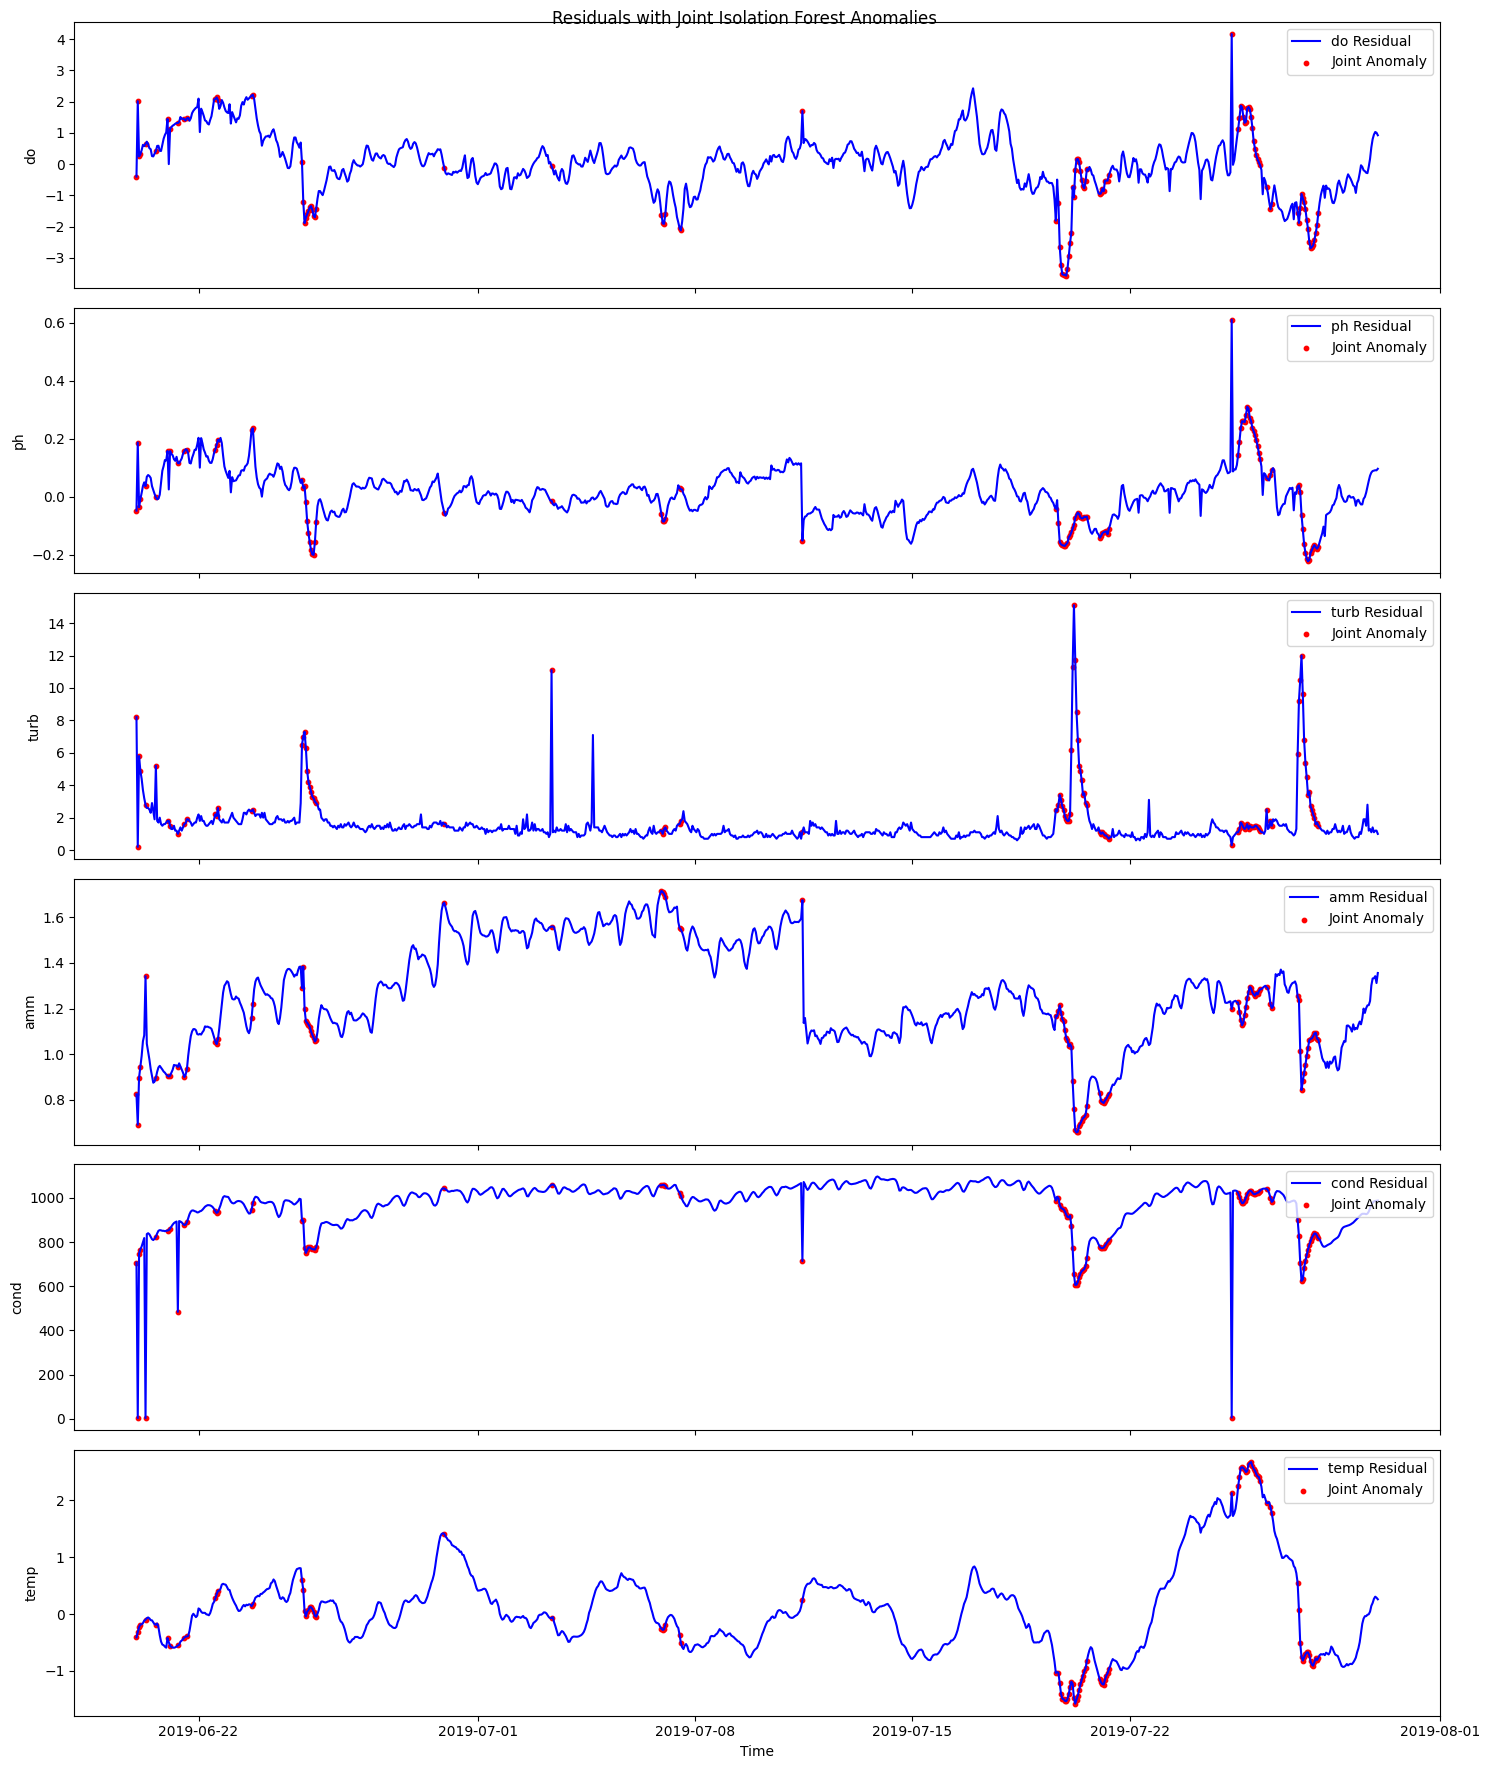

In [11]:

# ----- Step 1: Compute Isolation Forest anomalies jointly -----
clf = IsolationForest(contamination='auto', random_state=42)
preds = clf.fit_predict(residuals)

# Flag anomalies: 1 = anomaly, 0 = normal
residuals_anom = pd.Series((preds == -1).astype(int), index=residuals.index, name="joint_anomaly")

# ----- Step 2: Plot residuals with anomalies -----
variables = residuals.columns
n_vars = len(variables)

# Always create a new figure to avoid overlap
fig, axs = plt.subplots(n_vars, 1, figsize=(15, 3*n_vars), sharex=True)

# Ensure axs is iterable even for n_vars = 1
if n_vars == 1:
    axs = [axs]

for i, col in enumerate(variables):
    axs[i].plot(residuals.index, residuals[col], label=f'{col} Residual', color='blue')
    
    # Highlight anomalies in red (joint anomalies)
    anom_idx = residuals.index[residuals_anom == 1]  # safer alignment
    axs[i].scatter(anom_idx, residuals.loc[anom_idx, col], color='red', label='Joint Anomaly', s=10)
    
    axs[i].set_ylabel(col)
    axs[i].legend(loc='upper right')

plt.xlabel("Time")
plt.suptitle("Residuals with Joint Isolation Forest Anomalies")
plt.tight_layout()
# Save figure as PNG
plt.savefig("residuals_with_anomalies.png", dpi=600)  # dpi=300 gives high-quality image
plt.show()

In [12]:
# Combine residuals and anomalies into one DataFrame
residuals_combined = residuals.copy()  # start with residuals
residuals_combined['joint_anomaly'] = residuals_anom  # add anomaly column

# Optional: check the first few rows
print(residuals_combined.head())

                           do        ph  turb    amm   cond      temp  \
dateTime                                                                
2019-06-20 00:00:00 -0.399602 -0.048199   8.2  0.824  707.0 -0.408353   
2019-06-20 01:00:00  2.011036  0.186767   0.2  0.691    3.0 -0.319683   
2019-06-20 02:00:00  0.244680 -0.036508   5.8  0.897  748.0 -0.228554   
2019-06-20 03:00:00  0.313245 -0.009359   4.9  0.944  766.0 -0.184325   
2019-06-20 04:00:00  0.443309  0.012629   4.4  0.992  780.0 -0.180202   

                     joint_anomaly  
dateTime                            
2019-06-20 00:00:00              1  
2019-06-20 01:00:00              1  
2019-06-20 02:00:00              1  
2019-06-20 03:00:00              1  
2019-06-20 04:00:00              0  


# Combine Residuals with Anomaly Flags

- Create a **Series `residuals_anom`** from the joint Isolation Forest model (`1 = anomaly, 0 = normal`).   
- Resulting DataFrame contains both **residual values** and a **unified anomaly indicator** for easy analysis.


In [13]:
# residuals_anom is a Series from joint model
residuals_anom = pd.Series(
    (preds == -1).astype(int),
    index=residuals.index,
    name="any_anomaly"
)

# Merge residuals and anomaly flag into one DataFrame
residuals_with_flags = residuals.copy()
residuals_with_flags["any_anomaly"] = residuals_anom


In [14]:
# Make a copy to avoid modifying the original
Tidied_DF = Tidied_DF.copy()

# Add default anomaly columns
Tidied_DF['Anomalous'] = 0
for col in residuals.columns:
    Tidied_DF[f"{col}_anomaly"] = 0

# Fill in anomalies from joint residuals_anom
anomaly_idx = residuals_anom.index[residuals_anom == 1]
Tidied_DF.loc[anomaly_idx, 'Anomalous'] = 1
for col in residuals.columns:
    Tidied_DF.loc[anomaly_idx, f"{col}_anomaly"] = 1  # mark all as 1 if joint anomaly


# Rename 'any_anomaly' column to 'Anomalous'
Tidied_DF.rename(columns={'any_anomaly': 'Anomalous'}, inplace=True)    
    
# Check first 10 rows
print(Tidied_DF.head(10))


                       do    ph  turb    amm   cond   temp  Anomalous  \
dateTime                                                                
2019-06-20 00:00:00  5.40  7.23   8.2  0.824  707.0  18.10          1   
2019-06-20 01:00:00  9.20  7.63   0.2  0.691    3.0  18.15          1   
2019-06-20 02:00:00  5.52  7.20   5.8  0.897  748.0  18.23          1   
2019-06-20 03:00:00  5.23  7.21   4.9  0.944  766.0  18.25          1   
2019-06-20 04:00:00  5.08  7.22   4.4  0.992  780.0  18.22          0   
2019-06-20 05:00:00  5.12  7.23   3.7  1.057  799.0  18.20          0   
2019-06-20 06:00:00  4.94  7.24   3.2  1.083  818.0  18.20          0   
2019-06-20 07:00:00  5.10  7.21   2.8  1.342    3.0  18.19          1   
2019-06-20 08:00:00  5.42  7.28   2.6  1.046  836.0  18.27          0   
2019-06-20 09:00:00  5.73  7.31   2.6  1.011  840.0  18.35          0   

                     do_anomaly  ph_anomaly  turb_anomaly  amm_anomaly  \
dateTime                                         

In [15]:
# Keep only rows where any one variable is anomalous. Note that we filter all the variable even if one value is anomalous
Anomalous_DF = residuals_with_flags[Tidied_DF['Anomalous'] == 1]

# Clustering
The goal is to analyze multivariate residuals from sensor or time series data to detect unusual patterns and deviations. By scaling the data, performing clustering, and visualisation, we can identify relationships between variables, highlight periods of abnormal behavior, and summarize complex high-dimensional information in a comprehensible 2D biplot. This approach aids in monitoring, anomaly detection, and decision-making for environmental, industrial, or scientific datasets.

# PCA Biplot

A **PCA biplot** is a visualization tool that combines **principal component analysis (PCA)** results with information about the original variables:

- **Principal Components (PCs):** The points in the biplot represent the observations (rows of your data) projected onto the first two principal components (PC1 and PC2), which capture the largest variance in the dataset.
- **Variable Vectors:** Arrows indicate the contribution (loadings) of each original variable to the PCs. The direction and length show how strongly each variable influences the components.
- **Interpretation:**
  - Points close together have similar patterns across variables.
  - Arrows pointing in the same direction indicate correlated variables.
  - Arrows perpendicular to each other indicate variables that are uncorrelated.
- **Use in Residual Clustering:** In your workflow, the PCA biplot helps to visualize **how residuals (or deviations) cluster together** and how each variable contributes to cluster separation.

✅ **Benefit:** It reduces high-dimensional data to two dimensions while preserving as much variance as possible, making patterns easier to interpret visually.



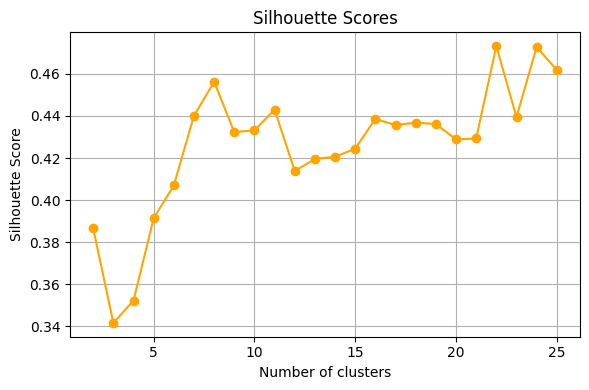

Silhouette suggests k=22


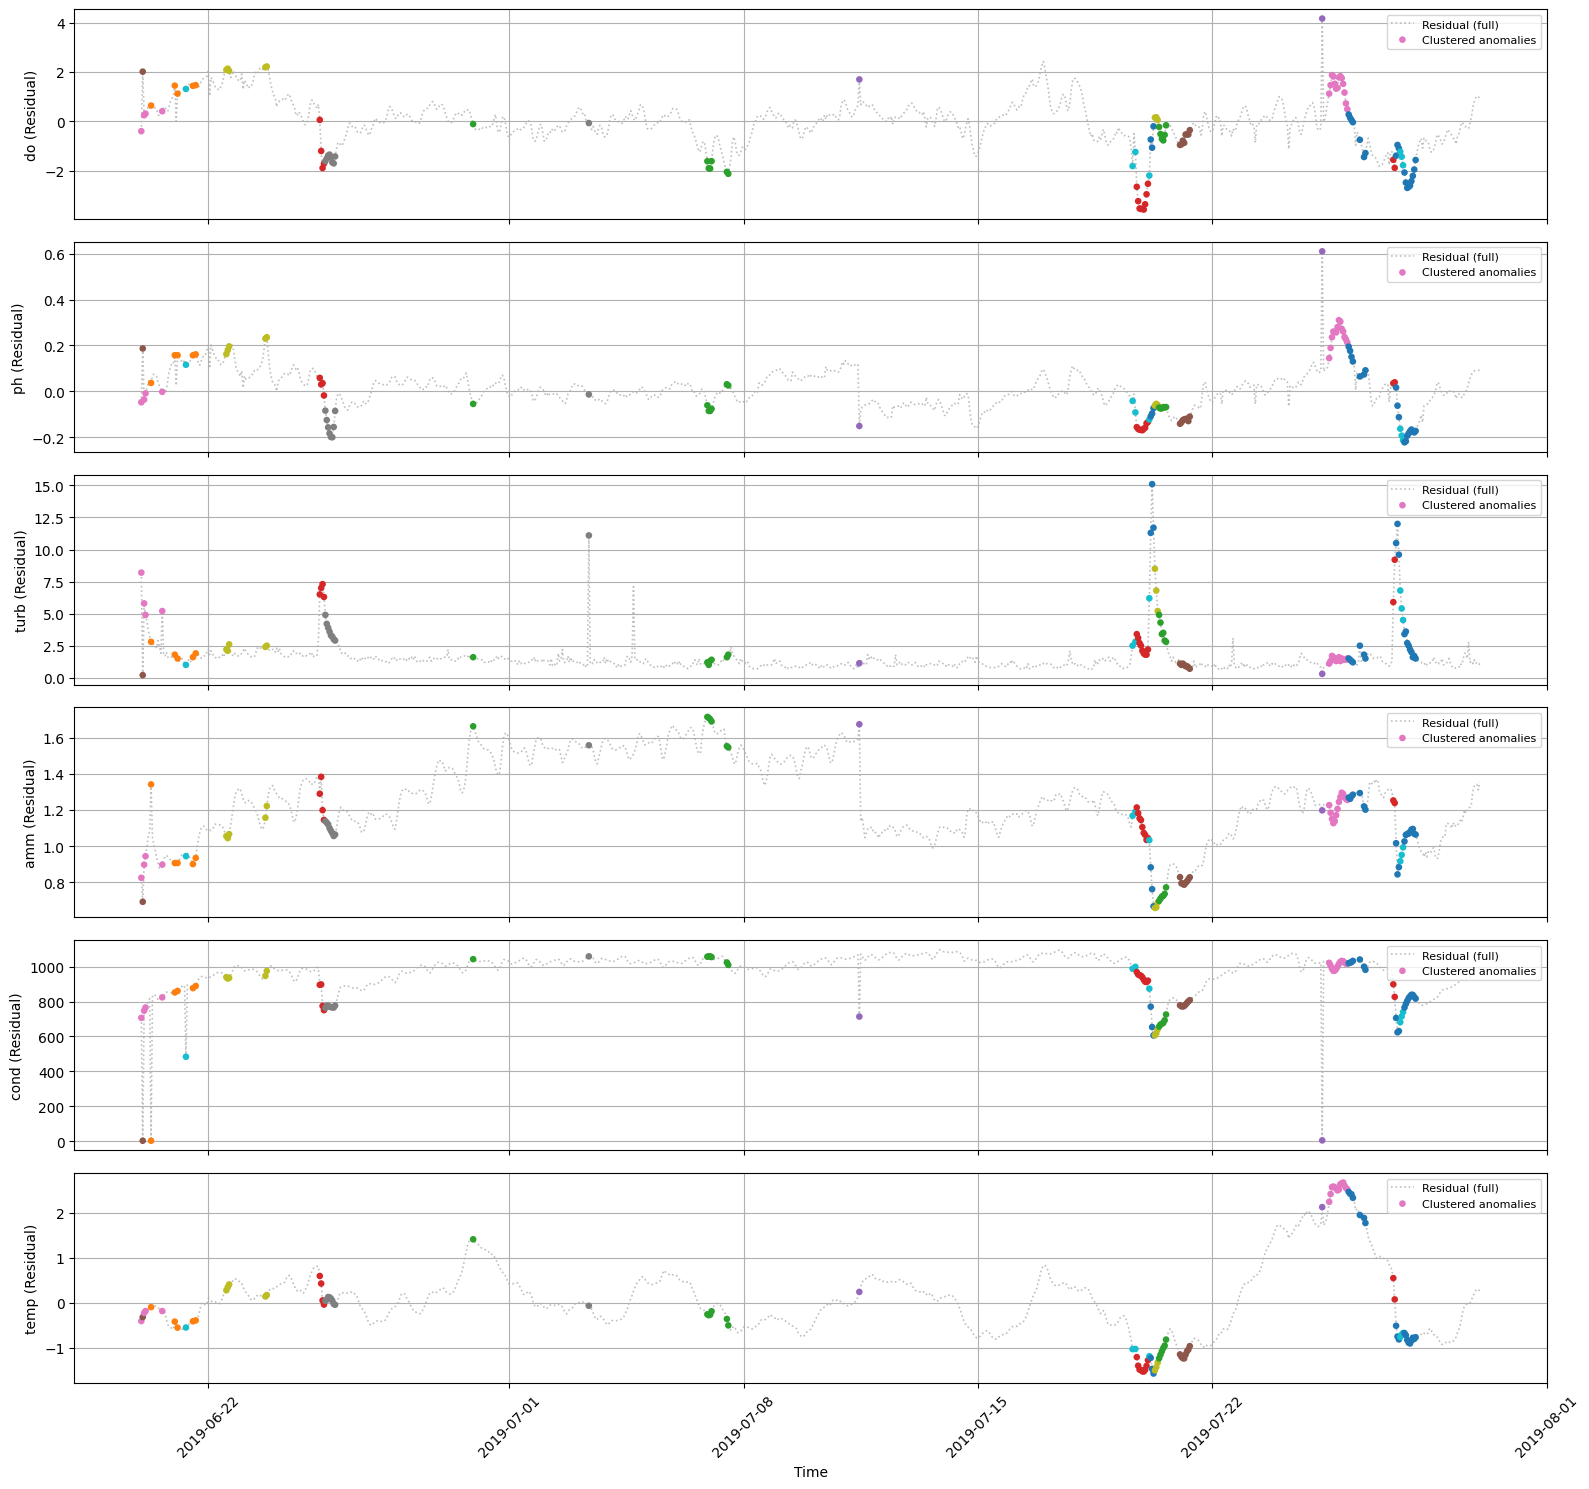

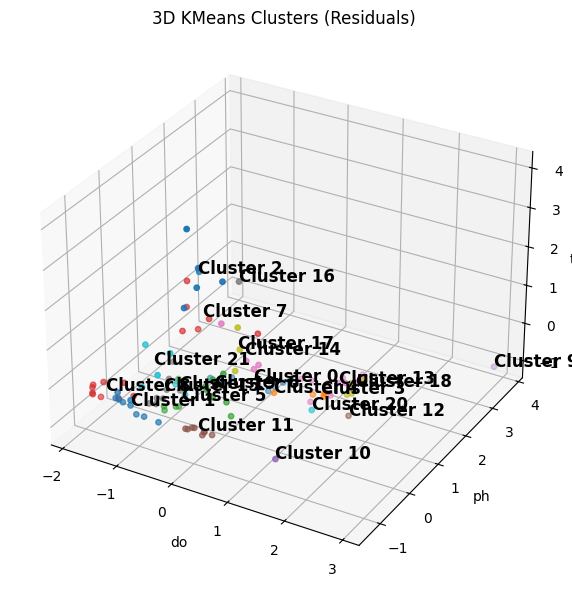

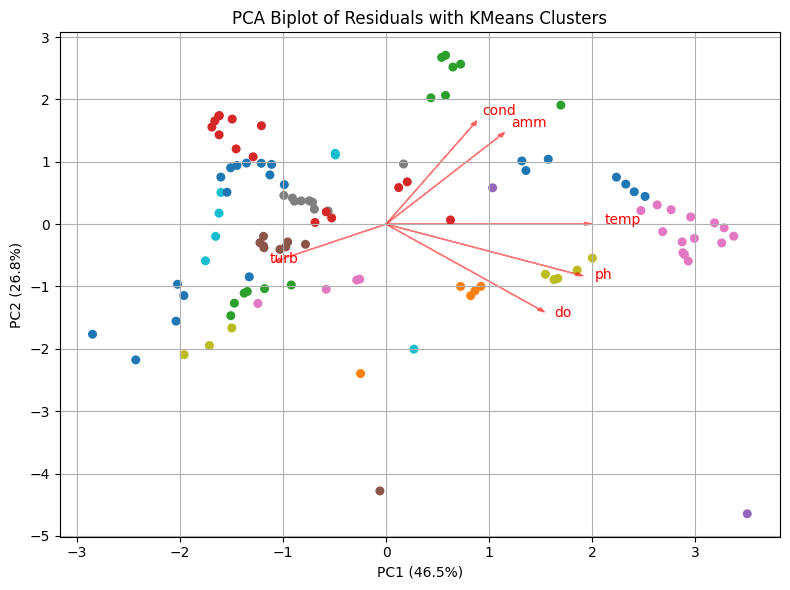

In [16]:
# --- Full residuals (background dotted lines) ---
full_residuals = residuals.copy()
if "any_anomaly" in full_residuals.columns:
    full_residuals = full_residuals.drop(columns=["any_anomaly"])

# --- Filtered anomalies (for clustering) ---
filtered_residuals = Anomalous_DF.copy()
if "any_anomaly" in filtered_residuals.columns:
    filtered_residuals = filtered_residuals.drop(columns=["any_anomaly"])

# --- Recompute feature names AFTER dropping unwanted columns ---
feature_names = filtered_residuals.columns.tolist()


# ================== Step 1: Scaling ==================
scaler_resid = StandardScaler()
X_resid = scaler_resid.fit_transform(filtered_residuals)

# ================== Step 2: Determine optimal k using Silhouette ==================
def optimal_k(X, max_k=25):
    sil_scores = []

    for k in range(2, max_k + 1):
        kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
        labels = kmeans.fit_predict(X)
        sil_scores.append(silhouette_score(X, labels))

    # Plot Silhouette
    plt.figure(figsize=(6,4))
    plt.plot(range(2, max_k+1), sil_scores, marker='o', color='orange')
    plt.xlabel('Number of clusters')
    plt.ylabel('Silhouette Score')
    plt.title('Silhouette Scores')
    plt.grid(True)
    plt.tight_layout()
    plt.savefig("silhouette_scores.png", dpi=600)  # Save figure
    plt.show()

    k_opt = np.argmax(sil_scores) + 2
    print(f"Silhouette suggests k={k_opt}")
    return k_opt

k_resid = optimal_k(X_resid)

# ================== Step 3: KMeans on residuals ==================
kmeans_resid = KMeans(n_clusters=k_resid, random_state=42, n_init=50)
filtered_residuals['ClusterID'] = kmeans_resid.fit_predict(X_resid)
labels_resid = filtered_residuals['ClusterID'].values

# ================== Step 4: Time Series Plots ==================
fig, axs = plt.subplots(
    len(feature_names),
    1,
    figsize=(16, 2.5 * len(feature_names)),
    sharex=True
)

if len(feature_names) == 1:
    axs = [axs]

colors = plt.get_cmap('tab10', k_resid)

for i, col in enumerate(feature_names):

    # ---- FULL residual time series (background) ----
    # Slightly darker dotted line (still transparent)
    # Background full residuals in light grey
    axs[i].plot(
        full_residuals.index,
        full_residuals[col],
        linestyle=":",        # dotted line
        linewidth=1.2,
        color="grey",         # light grey for background
        alpha=0.5,            # transparency, can adjust 0.4–0.6
        zorder=1,
        label="Residual (full)"
    )


    # ---- FILTERED anomalies (clustered) ----
    axs[i].scatter(
        filtered_residuals.index,
        filtered_residuals[col],
        c=[colors(l) for l in labels_resid],
        s=14,
        zorder=2,
        label="Clustered anomalies"
    )

    axs[i].set_ylabel(f"{col} (Residual)")
    axs[i].grid(True)
    axs[i].legend(loc="upper right", fontsize=8)

axs[-1].set_xlabel("Time")

if pd.api.types.is_datetime64_any_dtype(full_residuals.index):
    axs[-1].xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))

plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(
    "residuals_timeseries.png",
    dpi=600,
    bbox_inches="tight",
    pad_inches=0.02
)
plt.show()

# ================== Step 5: Adaptive Cluster Visualization ==================
if X_resid.shape[1] >= 2:
    if X_resid.shape[1] == 2:
        # 2D scatter
        fig, ax = plt.subplots(figsize=(8,6))
        ax.scatter(X_resid[:,0], X_resid[:,1], 
                   c=[colors(l) for l in labels_resid], s=30)
        centroids = kmeans_resid.cluster_centers_
        ax.scatter(centroids[:,0], centroids[:,1], marker='X', c='black', s=100, label='Centroids')
        ax.set_xlabel(feature_names[0])
        ax.set_ylabel(feature_names[1])
        ax.set_title('2D KMeans Clusters (Residuals)')
        ax.legend()
        plt.grid(True)
        plt.tight_layout()
        plt.savefig("kmeans_2D_residuals.png", dpi=600)
        plt.show()
    else:
        # 3D scatter
        fig_cluster = plt.figure(figsize=(12,6))
        ax = fig_cluster.add_subplot(111, projection='3d')
        X_plot = X_resid[:, :3]

        ax.scatter(X_plot[:,0], X_plot[:,1], X_plot[:,2],
                   c=[colors(l) for l in labels_resid], s=15)

        centroids = kmeans_resid.cluster_centers_[:, :3]
        for i, centroid in enumerate(centroids):
            ax.text(centroid[0], centroid[1], centroid[2],
                    f'Cluster {i}', fontsize=12, fontweight='bold', color='black')

        ax.set_title('3D KMeans Clusters (Residuals)')
        ax.set_xlabel(feature_names[0])
        ax.set_ylabel(feature_names[1])
        ax.set_zlabel(feature_names[2])
        plt.tight_layout()
        plt.savefig("kmeans_3D_residuals.png", dpi=600)
        plt.show()
else:
    print("Skipping cluster visualization (not enough features).")

# --- Build display names for features ---
display_names = []
for feature in feature_names:
    if feature.lower() in ["any_anomaly", "anomalous"]:
        display_names.append("Deviation")
    elif feature.endswith("_anomaly"):
        base = feature.replace("_anomaly", "").upper()
        display_names.append(f"{base} Deviation")
    else:
        display_names.append(feature)

# --- PCA Biplot ---
if X_resid.shape[1] > 2:
    pca = PCA(n_components=2)
    X_pca = pca.fit_transform(X_resid)

    fig, ax = plt.subplots(figsize=(8,6))
    scatter = ax.scatter(X_pca[:,0], X_pca[:,1], c=labels_resid, cmap='tab10', s=30)
    ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
    ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
    ax.set_title('PCA Biplot of Residuals with KMeans Clusters')

    for i, label in enumerate(display_names):
        ax.arrow(0, 0,
                 pca.components_[0,i]*max(X_pca[:,0]),
                 pca.components_[1,i]*max(X_pca[:,1]),
                 color='r', alpha=0.5, head_width=0.05)
        ax.text(pca.components_[0,i]*max(X_pca[:,0])*1.1,
                pca.components_[1,i]*max(X_pca[:,1])*1.1, label, color='r')

    plt.grid(True)
    plt.tight_layout()
    plt.savefig("pca_biplot_residuals.png", dpi=600)
    plt.show()
else:
    print("Skipping PCA biplot (not enough features).")


In [17]:
# If dateTime is the index, reset it to make it a column
filtered_residuals = filtered_residuals.reset_index()

# Keep only the dateTime column (now a regular column) and ClusterID
filtered_residuals = filtered_residuals[['dateTime', 'ClusterID']]

In [18]:
# Ensure dateTime is a column in both DataFrames
Tidied_DF = Tidied_DF.reset_index() if 'dateTime' not in Tidied_DF.columns else Tidied_DF
filtered_residuals = filtered_residuals.reset_index() if 'dateTime' not in filtered_residuals.columns else filtered_residuals

# Merge ClusterID
Tidied_DF = Tidied_DF.merge(
    filtered_residuals[['dateTime', 'ClusterID']],
    on='dateTime',
    how='left'   # left join keeps all rows from Tidied_DF
)

# Keep only main columns + ClusterID
columns_to_keep = ['dateTime', 'do', 'ph', 'turb', 'amm', 'cond', 'temp', 'ClusterID']
Tidied_DF = Tidied_DF[columns_to_keep]

print(Tidied_DF.head(50))

              dateTime    do    ph  turb    amm   cond    temp  ClusterID
0  2019-06-20 00:00:00  5.40  7.23  8.20  0.824  707.0  18.100       14.0
1  2019-06-20 01:00:00  9.20  7.63  0.20  0.691    3.0  18.150       12.0
2  2019-06-20 02:00:00  5.52  7.20  5.80  0.897  748.0  18.230       14.0
3  2019-06-20 03:00:00  5.23  7.21  4.90  0.944  766.0  18.250       14.0
4  2019-06-20 04:00:00  5.08  7.22  4.40  0.992  780.0  18.220        NaN
5  2019-06-20 05:00:00  5.12  7.23  3.70  1.057  799.0  18.200        NaN
6  2019-06-20 06:00:00  4.94  7.24  3.20  1.083  818.0  18.200        NaN
7  2019-06-20 07:00:00  5.10  7.21  2.80  1.342    3.0  18.190        4.0
8  2019-06-20 08:00:00  5.42  7.28  2.60  1.046  836.0  18.270        NaN
9  2019-06-20 09:00:00  5.73  7.31  2.60  1.011  840.0  18.350        NaN
10 2019-06-20 10:00:00  6.12  7.34  2.50  0.977  835.0  18.410        NaN
11 2019-06-20 11:00:00  6.46  7.38  2.30  0.935  824.0  18.440        NaN
12 2019-06-20 12:00:00  6.60  7.41  2.

In [19]:
# List of water quality variables
vars_to_plot = ['do', 'ph', 'turb', 'amm', 'cond', 'temp']

# Create output folder for boxplots
out_dir = "boxplots"
os.makedirs(out_dir, exist_ok=True)

# Plot boxplots per variable grouped by ClusterID
for var in vars_to_plot:
    plt.figure(figsize=(8,6))
    
    # Boxplot with ClusterID colors
    ax = sns.boxplot(
        x='ClusterID',
        y=var,
        data=Tidied_DF,
        hue='ClusterID',
        palette='tab10',
        dodge=False,    # avoid separating hues since x=ClusterID
        showmeans=True  # show mean marker
    )
    
    # Remove redundant legend
    ax.get_legend().remove()
    
    # Annotate cluster sizes on top of boxes
    cluster_counts = Tidied_DF['ClusterID'].value_counts().sort_index()
    for i, count in enumerate(cluster_counts):
        ax.text(i, Tidied_DF[var].max()*1.02, f'n={count}', ha='center', fontsize=9)
    
    plt.title(f'Boxplot of {var.upper()} by ClusterID')
    plt.xlabel('Cluster ID')
    plt.ylabel(var.upper())
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    
    # Save figure
    plot_path = os.path.join(out_dir, f'boxplot_{var}_by_cluster.png')
    plt.savefig(plot_path, dpi=600)
    plt.close()

print(f"Boxplots saved in folder: {out_dir}")

Boxplots saved in folder: boxplots


# ClusterID Over Time

This plot visualizes the evolution of cluster assignments (`ClusterID`) over time, ignoring any missing values (`NaN`). Each point represents a timestamped observation colored by its cluster. This allows us to observe temporal patterns, transitions between clusters, and periods of similar behavior in the residual data.

- **X-axis:** Date and time (`dateTime`)  
- **Y-axis:** Cluster assignment (`ClusterID`)  
- **Color:** Cluster label for easier visual distinction  
- **NaNs:** Rows with missing `ClusterID` are ignored


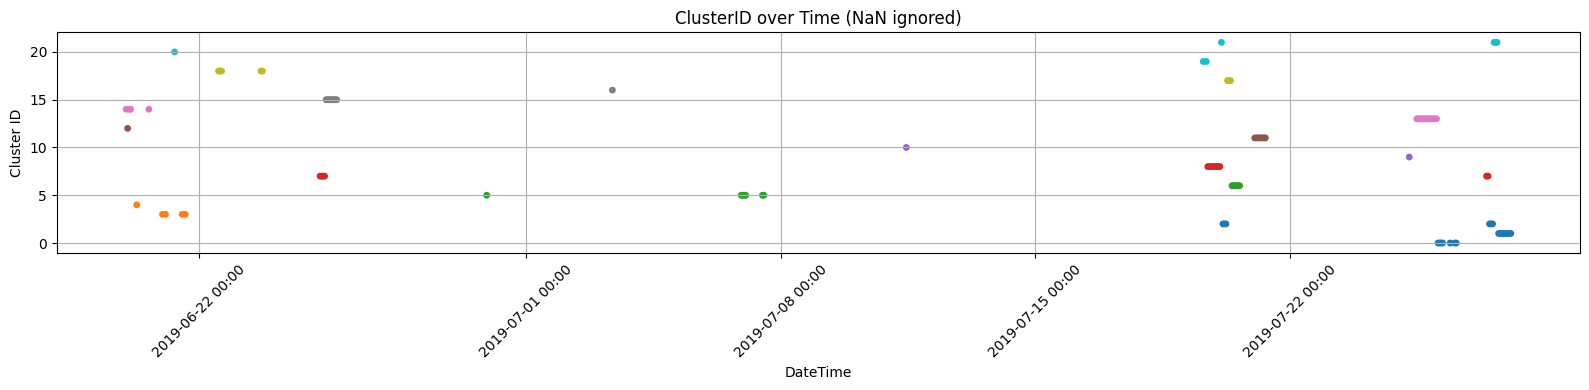

In [20]:


# Ensure dateTime is datetime
Tidied_DF['dateTime'] = pd.to_datetime(Tidied_DF['dateTime'])

# Filter out rows where ClusterID is NaN
plot_df = Tidied_DF.dropna(subset=['ClusterID'])

plt.figure(figsize=(16,4))
plt.scatter(plot_df['dateTime'], plot_df['ClusterID'], c=plot_df['ClusterID'], cmap='tab10', s=15)
plt.xlabel('DateTime')
plt.ylabel('Cluster ID')
plt.title('ClusterID over Time (NaN ignored)')
plt.grid(True)

# Format x-axis nicely
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d %H:%M'))
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


# Save Clustered Residuals

After clustering, the filtered residuals with their corresponding `ClusterID` are saved for downstream analysis or reporting. The output is stored in a dedicated directory to keep results organized.

- **Output directory:** `clustered_residuals`  
- **File name:** `Tidied_DF.csv`  
- **Contents:** Filtered residuals with assigned cluster numbers (`ClusterID`)  
- **Purpose:** Preserve the clustering results for future use, visualization, or further statistical analysis  

✅ **Note:** Missing cluster assignments (`NaN`) were already excluded before saving.


In [21]:
# ================== Save clustered residuals ==================
output_dir = "clustered_residuals"
os.makedirs(output_dir, exist_ok=True)
csv_path = os.path.join(output_dir, "Tidied_DF.csv")
plot_df.to_csv(csv_path, index=True)
print(f"✅ Processing Complete. Clustered residuals with cluster numbers saved to: {csv_path}")

✅ Processing Complete. Clustered residuals with cluster numbers saved to: clustered_residuals/Tidied_DF.csv
